In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
import time
from gravity_forward_numpy import gsphere
from gravity_forward_numba import VecWerSch_numba

In [ ]:
# Sphere parameters
xc, yc, zc = 0, 0, 2
a = 1.999
rho = 1000.0

# Observation grid (same as your original)
xgv = np.linspace(-10., 10., 51)
ygv = np.linspace(-10., 10., 51)
z0 = 0.0
X2d, Y2d = np.meshgrid(xgv, ygv)
Z2d = z0 * np.ones(X2d.shape)
P = np.column_stack((X2d.ravel(), Y2d.ravel(), Z2d.ravel()))

# Analytical reference solution
V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Tyy_ref, Tzz_ref, Txy_ref, Txz_ref, Tyz_ref = \
    gsphere(P[:,0], P[:,1], P[:,2], xc, yc, zc, a, rho)

fields = ['V', 'gx', 'gy', 'gz', 'Txx', 'Tyy', 'Tzz', 'Txy', 'Txz', 'Tyz']
ref_arrays = [V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Tyy_ref, Tzz_ref, Txy_ref, Txz_ref, Tyz_ref]

# Refinement settings
nsub_max = 11
NSUBs = np.arange(nsub_max)

# Geographic resolution rules
Lon_Res = 5 * (2 ** NSUBs)
Lat_Res = (2 ** (NSUBs + 1)) + 2

# Initialize error dictionaries and time arrays
err_ico = {f: [] for f in fields}
err_geo = {f: [] for f in fields}
time_ico = []
time_geo = []

In [ ]:
# L2 norm errors and time costs for both methods
for idx, nsub in enumerate(NSUBs):
    print(f"Processing nsub = {nsub}...")

    # --- Icosphere ---
    mesh_ico = pv.Icosphere(radius=a, center=(xc, yc, zc), nsub=nsub)
    verts_ico = mesh_ico.points
    faces_ico = mesh_ico.regular_faces

    t0 = time.time()
    V_i, gx_i, gy_i, gz_i, Txx_i, Tyy_i, Tzz_i, Txy_i, Txz_i, Tyz_i = \
        VecWerSch_numba(P, verts_ico, faces_ico, rho)
    t_ico = time.time() - t0
    time_ico.append(t_ico)
    
    cal_ico = [V_i, gx_i, gy_i, gz_i, Txx_i, Tyy_i, Tzz_i, Txy_i, Txz_i, Tyz_i]
    for field, ref, cal in zip(fields, ref_arrays, cal_ico):
        norm_ref = np.linalg.norm(ref)
        err = np.linalg.norm(cal - ref) / norm_ref
        err_ico[field].append(err)

    # --- Geographic Grid ---
    theta_res = Lon_Res[idx]
    phi_res   = Lat_Res[idx]
    mesh_geo = pv.Sphere(radius=a, center=(xc, yc, zc),
                         theta_resolution=theta_res,
                         phi_resolution=phi_res)
    verts_geo = mesh_geo.points
    faces_geo = mesh_geo.regular_faces

    t0 = time.time()
    V_g, gx_g, gy_g, gz_g, Txx_g, Tyy_g, Tzz_g, Txy_g, Txz_g, Tyz_g = \
        VecWerSch_numba(P, verts_geo, faces_geo, rho)
    t_geo = time.time() - t0
    time_geo.append(t_geo)
    
    cal_geo = [V_g, gx_g, gy_g, gz_g, Txx_g, Tyy_g, Tzz_g, Txy_g, Txz_g, Tyz_g]
    for field, ref, cal in zip(fields, ref_arrays, cal_geo):
        norm_ref = np.linalg.norm(ref)
        err = np.linalg.norm(cal - ref) / norm_ref 
        err_geo[field].append(err)

Processing nsub = 0...
Processing nsub = 1...
Processing nsub = 2...
Processing nsub = 3...
Processing nsub = 4...
Processing nsub = 5...
Processing nsub = 6...
Processing nsub = 7...
Processing nsub = 8...
Processing nsub = 9...
Processing nsub = 10...


In [ ]:
# Create DataFrames including computation time
df_ico = pd.DataFrame(err_ico, index=NSUBs)
df_ico['Time (s)'] = time_ico

df_geo = pd.DataFrame(err_geo, index=NSUBs)
df_geo['Time (s)'] = time_geo

print("\n" + "="*80)
print("Relative L2 Errors + Computation Time: Icosphere vs Analytical Sphere")
print("GP in m^2/s^2, GV in mGal, GGT in Eotvos")
print("="*80)
print(df_ico.to_string(float_format="{:.2e}".format))

print("\n" + "="*80)
print("Relative L2 Errors + Computation Time: Geographic Grid vs Analytical Sphere")
print("GP in m^2/s^2, GV in mGal, GGT in Eotvos")
print("="*80)
print(df_geo.to_string(float_format="{:.2e}".format))


Relative L2 Errors + Computation Time: Icosphere vs Analytical Sphere
GP in m^2/s^2, GV in mGal, GGT in Eotvos
          V       gx       gy       gz      Txx      Tyy      Tzz      Txy      Txz      Tyz  Time (s)
0  3.95e-01 3.94e-01 3.95e-01 3.95e-01 3.94e-01 4.07e-01 4.00e-01 4.01e-01 3.96e-01 4.05e-01  1.66e+00
1  1.27e-01 1.27e-01 1.27e-01 1.26e-01 2.59e-01 2.18e-01 2.74e-01 1.31e-01 1.31e-01 1.31e-01  2.70e-03
2  3.38e-02 3.39e-02 3.39e-02 3.36e-02 1.17e-01 1.05e-01 1.33e-01 3.73e-02 3.93e-02 3.76e-02  3.44e-03
3  8.62e-03 8.63e-03 8.63e-03 8.58e-03 5.00e-02 4.70e-02 5.87e-02 9.92e-03 1.07e-02 9.32e-03  1.02e-02
4  2.17e-03 2.17e-03 2.17e-03 2.15e-03 2.00e-02 1.98e-02 2.42e-02 2.22e-03 2.20e-03 2.52e-03  3.79e-02
5  5.42e-04 5.42e-04 5.43e-04 5.38e-04 7.76e-03 7.79e-03 9.51e-03 5.55e-04 5.45e-04 5.52e-04  1.45e-01
6  1.36e-04 1.36e-04 1.36e-04 1.35e-04 2.81e-03 2.87e-03 3.47e-03 1.39e-04 1.37e-04 1.40e-04  6.21e-01
7  3.40e-05 3.39e-05 3.40e-05 3.38e-05 9.10e-04 9.44e-04 1.13e-0

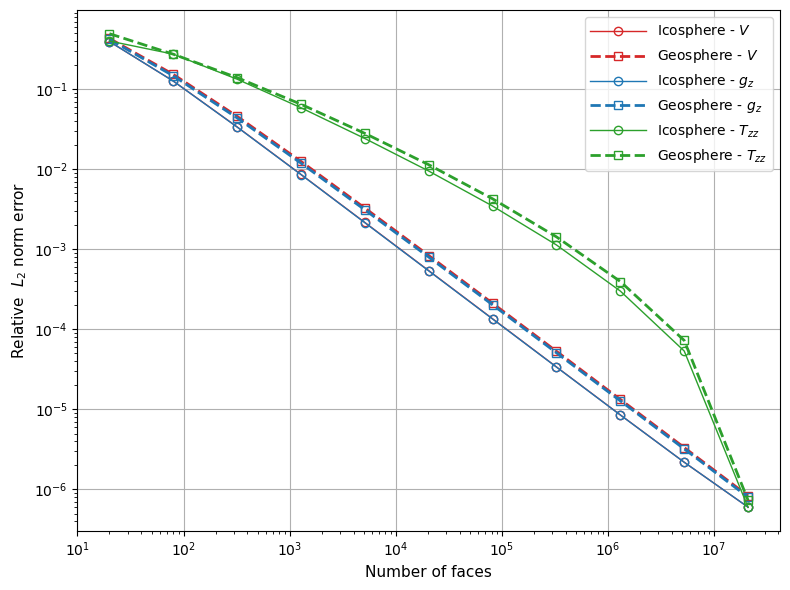

In [ ]:
# Plot representative components in three subplots
rep_fields = ['V', 'gz', 'Tzz']
latex_labels = {'V': r'$V$ ', 'gz': r'$g_z$ ', 'Tzz': r'$T_{zz}$ '}
colors = {'V': 'tab:red', 'gz': 'tab:blue', 'Tzz': 'tab:green'}

fig, ax = plt.subplots(figsize=(8, 6))

for idx, field in enumerate(rep_fields):
    label_latex = latex_labels[field]
    color = colors[field]

    # Icosphere
    ax.loglog(
        20*4**NSUBs, err_ico[field],
        linestyle='-', marker='o', fillstyle='none',
        color=color, linewidth=1, markersize=6,
        label=f'Icosphere - {label_latex}'
    )
    # Geographic Grid
    ax.loglog(
        20*4**NSUBs, err_geo[field],
        linestyle='--', marker='s', fillstyle='none',
        color=color, linewidth=2, markersize=6,
        label=f'Geosphere - {label_latex}'
    )

ax.set_ylabel(r'Relative  $L_2$ norm error', fontsize=11)
ax.grid(True, which="major")
ax.legend(
    fontsize=10,
    handlelength=4
)
ax.set_xlabel('Number of faces', fontsize=11)

plt.tight_layout()
plt.savefig("IcoGeoSphere_Local.png", dpi=300, bbox_inches='tight')
plt.show()